<a href="https://colab.research.google.com/github/VenkataAkashGurram/VenkataAkashGurram_INFO5731_Spring2026/blob/main/Gurram_Venkata_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Dataset Preview:
   document_id                                         clean_text sentiment
0            1  An emotional rollercoaster that left me in tea...  positive
1            2  The cinematography was award-worthy. Denis Vil...   neutral
2            3  Overrated. Too much style, not enough substanc...  negative
3            4  Disappointing sequel. The plot was confusing a...  negative
4            5  An emotional rollercoaster that left me in tea...  positive

Class Distribution:
sentiment
neutral     42
positive    34
negative    24
Name: count, dtype: int64


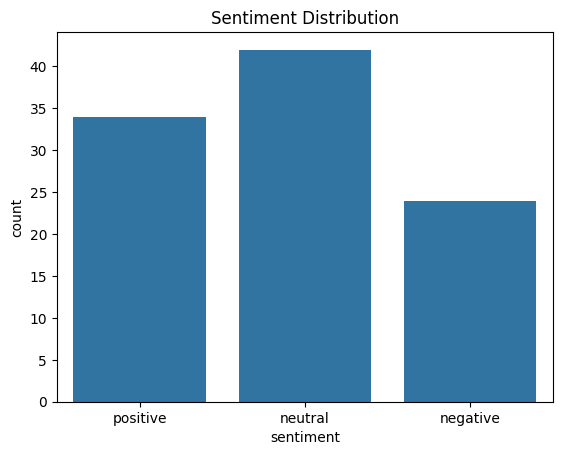

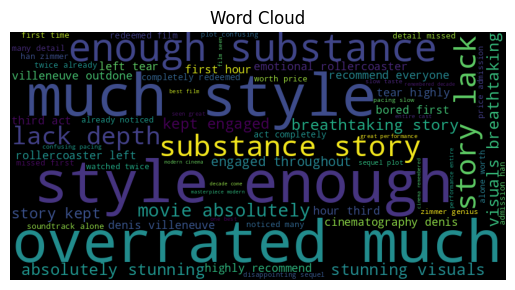

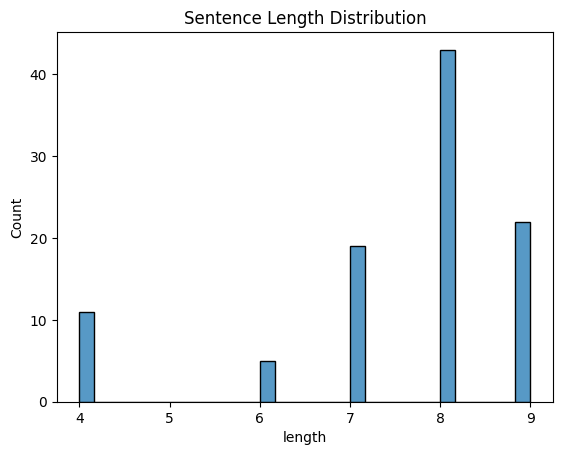


=== Naive Bayes ===
Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         5
     neutral       1.00      1.00      1.00         7
    positive       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


=== SVM ===
Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         5
     neutral       1.00      1.00      1.00         7
    positive       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


=== XGBoost ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


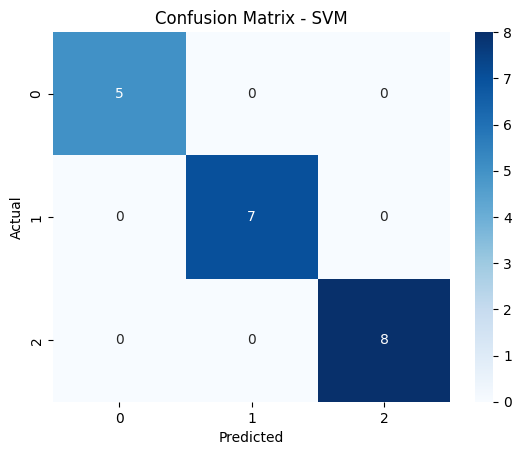


Best SVM Parameters: {'C': 0.1}

Sample Prediction: ['positive']


In [2]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Download NLP resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError

# ================================
# 2. LOAD DATASET  (FIXED NAME)
# ================================
df = pd.read_csv('imdb_reviews_annotated.csv')

print("Dataset Preview:")
print(df.head())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# ================================
# 3. PREPROCESSING
# ================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['processed_text'] = df['clean_text'].apply(preprocess)

# ================================
# 4. EDA
# ================================

# Sentiment Distribution
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Word Cloud
text = " ".join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# Sentence Length
df['length'] = df['processed_text'].apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(df['length'], bins=30)
plt.title("Sentence Length Distribution")
plt.show()

# ================================
# 5. FEATURE ENGINEERING
# ================================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['processed_text'])
y = df['sentiment']

# Encode labels for XGBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ================================
# 6. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# ================================
# 7. NAIVE BAYES
# ================================
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("\n=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# ================================
# 8. SVM
# ================================
svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\n=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ================================
# 9. XGBOOST
# ================================
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

xgb.fit(X_train_enc, y_train_enc)

y_pred_xgb = xgb.predict(X_test_enc)

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print(classification_report(y_test_enc, y_pred_xgb))

# ================================
# 10. CONFUSION MATRIX (SVM)
# ================================
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 11. HYPERPARAMETER TUNING
# ================================
params = {'C': [0.1, 1, 10]}

grid = GridSearchCV(LinearSVC(), params, cv=3)
grid.fit(X_train, y_train)

print("\nBest SVM Parameters:", grid.best_params_)

# ================================
# 12. SAMPLE PREDICTION
# ================================
sample_text = ["This movie was amazing and emotional"]
sample_vec = vectorizer.transform(sample_text)

prediction = svm.predict(sample_vec)

print("\nSample Prediction:", prediction)

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


Train Data:
    label                                               text
0      1  a stirring , funny and finally transporting re...
1      0  apparently reassembled from the cutting-room f...
2      0  they presume their audience wo n't sit still f...
3      1  this is a visually stunning rumination on love...
4      1  jonathan parker 's bartleby should have been t...

Test Data:
    label                                               text
0      0     no movement , no yuks , not much of anything .
1      0  a gob of drivel so sickly sweet , even the eag...
2      0  gangs of new york is an unapologetic mess , wh...
3      0  we never really feel involved with the story ,...
4      1            this is one of polanski 's best films .


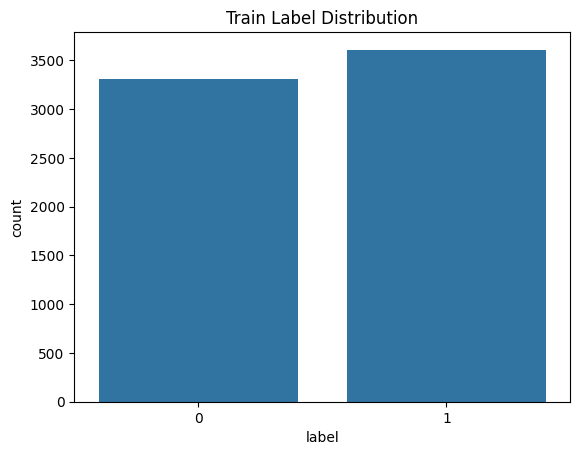

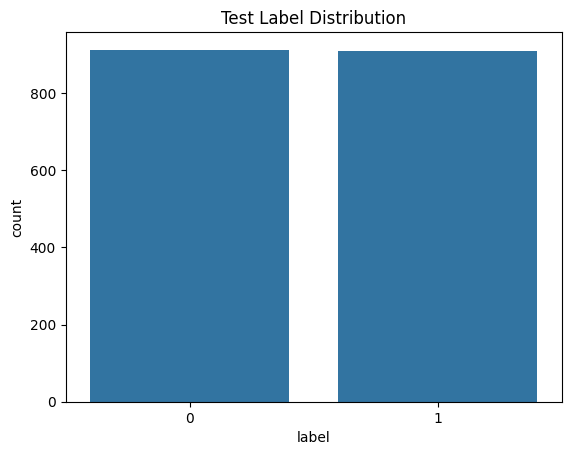

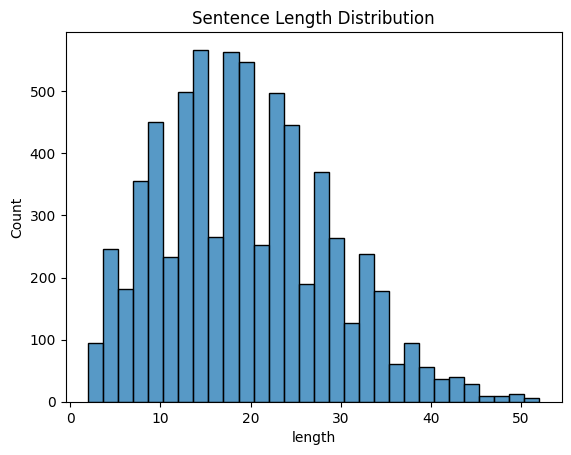


===== SVM =====
CV Accuracy: 0.7519904557353719

Validation Results:
Accuracy: 0.7695086705202312
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       671
           1       0.76      0.81      0.78       713

    accuracy                           0.77      1384
   macro avg       0.77      0.77      0.77      1384
weighted avg       0.77      0.77      0.77      1384


Test Results:
Accuracy: 0.7847336628226249
              precision    recall  f1-score   support

           0       0.80      0.75      0.78       912
           1       0.77      0.82      0.79       909

    accuracy                           0.78      1821
   macro avg       0.79      0.78      0.78      1821
weighted avg       0.79      0.78      0.78      1821


===== KNN =====
CV Accuracy: 0.509210019519392

Validation Results:
Accuracy: 0.5223988439306358
              precision    recall  f1-score   support

           0       0.50      0.78      0.61       

In [3]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ================================
# 2. LOAD DATASET
# ================================

def load_data(file_path):
    data = []
    with open(file_path, 'r', encoding='latin-1') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) == 2:
                label, text = parts
                data.append((int(label), text))
    return pd.DataFrame(data, columns=['label', 'text'])

train_df = load_data('stsa-train.txt')
test_df = load_data('stsa-test.txt')

print("Train Data:\n", train_df.head())
print("\nTest Data:\n", test_df.head())

# ================================
# 3. EDA
# ================================

# Train distribution
sns.countplot(x='label', data=train_df)
plt.title("Train Label Distribution")
plt.show()

# Test distribution
sns.countplot(x='label', data=test_df)
plt.title("Test Label Distribution")
plt.show()

# Sentence length
train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))

sns.histplot(train_df['length'], bins=30)
plt.title("Sentence Length Distribution")
plt.show()

# ================================
# 4. FEATURE ENGINEERING
# ================================
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(train_df['text'])
y = train_df['label']

X_test_final = vectorizer.transform(test_df['text'])
y_test_final = test_df['label']

# ================================
# 5. TRAIN-VALIDATION SPLIT (80-20)
# ================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 6. MODELS + 10-FOLD CV
# ================================

models = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # 10-Fold Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=10)
    print("CV Accuracy:", np.mean(cv_scores))

    # Train on full training set
    model.fit(X_train, y_train)

    # Validate
    y_val_pred = model.predict(X_val)
    print("\nValidation Results:")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print(classification_report(y_val, y_val_pred))

    # Test evaluation
    y_test_pred = model.predict(X_test_final)
    print("\nTest Results:")
    print("Accuracy:", accuracy_score(y_test_final, y_test_pred))
    print(classification_report(y_test_final, y_test_pred))

    results[name] = accuracy_score(y_test_final, y_test_pred)

# ================================
# 7. BEST MODEL
# ================================
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                                  Reviews
262853  I needed a texting phone that did not require ...
70999                                          Excellent!
324745  I recommend this excellent team for the many d...
114637  updated review. Purchased this phone on Novemb...
221325                                       battery fail


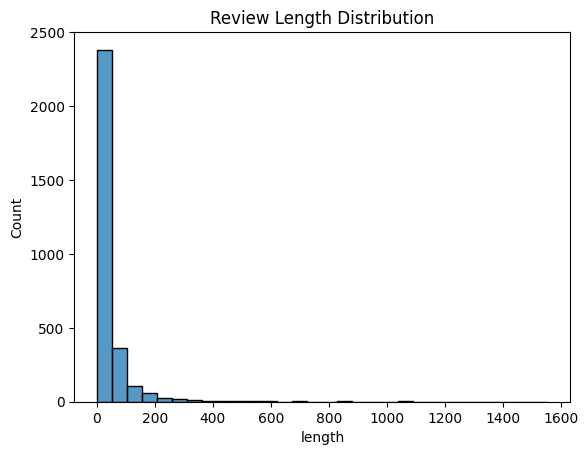

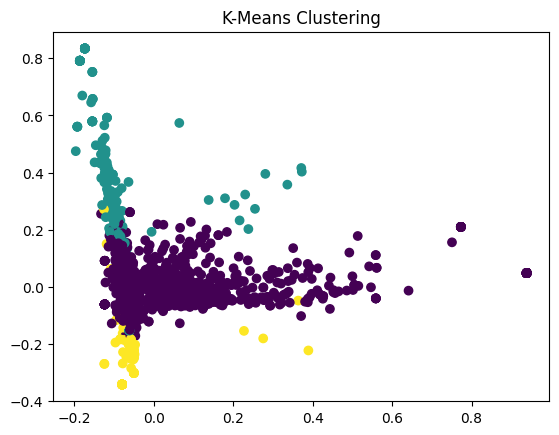

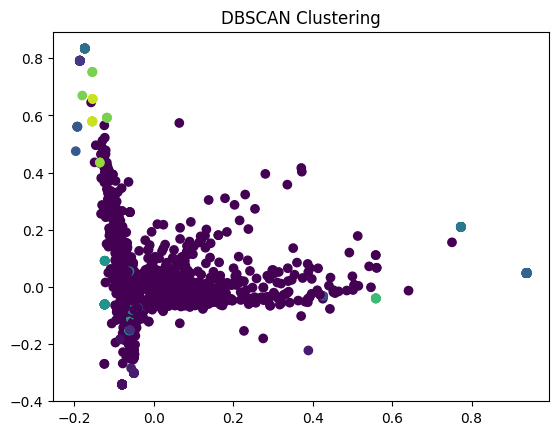

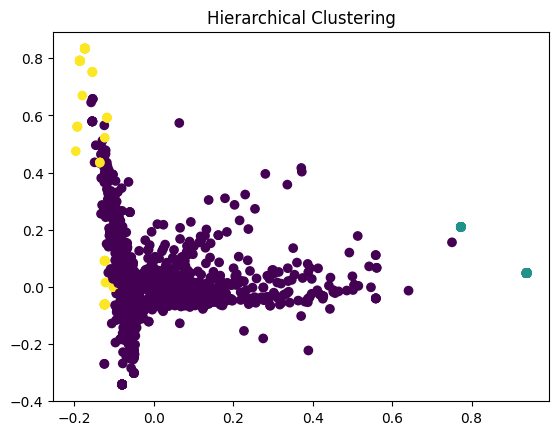

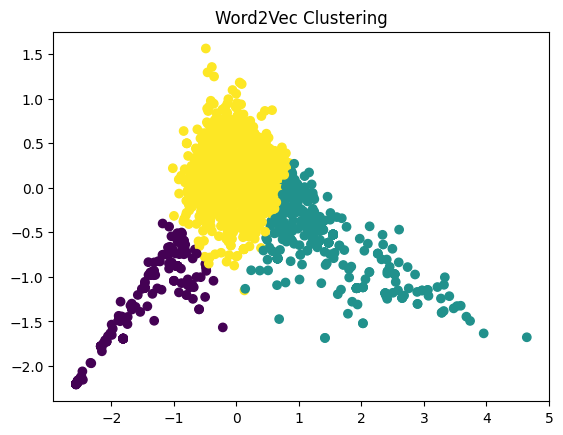

In [5]:
# ================================
# INSTALL (Fix gensim error)
# ================================
!pip install gensim nltk --quiet

# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

# ================================
# LOAD DATA
# ================================
df = pd.read_csv('Amazon_Unlocked_Mobile.csv')

df = df[['Reviews']].dropna()
df = df.sample(3000, random_state=42)

print(df.head())

# ================================
# EDA
# ================================
df['length'] = df['Reviews'].apply(lambda x: len(str(x).split()))

sns.histplot(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.show()

# ================================
# TF-IDF FEATURES
# ================================
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
X = vectorizer.fit_transform(df['Reviews'])
X_dense = X.toarray()

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# ================================
# K-MEANS
# ================================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_dense)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

# ================================
# DBSCAN
# ================================
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_dense)

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

# ================================
# HIERARCHICAL
# ================================
hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(X_dense)

plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels)
plt.title("Hierarchical Clustering")
plt.show()

# ================================
# WORD2VEC
# ================================
sentences = [word_tokenize(str(text).lower()) for text in df['Reviews']]

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

def get_vector(words):
    vec = np.zeros(100)
    count = 0
    for w in words:
        if w in w2v_model.wv:
            vec += w2v_model.wv[w]
            count += 1
    return vec / count if count != 0 else vec

w2v_vectors = np.array([get_vector(words) for words in sentences])

kmeans_w2v = KMeans(n_clusters=3, random_state=42)
w2v_labels = kmeans_w2v.fit_predict(w2v_vectors)

pca_w2v = PCA(n_components=2)
X_w2v_pca = pca_w2v.fit_transform(w2v_vectors)

plt.scatter(X_w2v_pca[:,0], X_w2v_pca[:,1], c=w2v_labels)
plt.title("Word2Vec Clustering")
plt.show()

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:** For this analysis, we implemented four clustering algorithms: K-means, DBSCAN, Hierarchical clustering and Word2Vec-based clustering. K-means offered well-defined clusters, but needed to know the number of clusters. DBSCAN helped detect outliers, but was sensitive to the number of dimensions. Hierarchical clustering formed hierarchical groups but was slower. Word2Vec clustering produced better quality clusters due to improved semantic understanding. In all, K-means and Word2Vec were the most successful, with DBSCAN being the weakest.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

